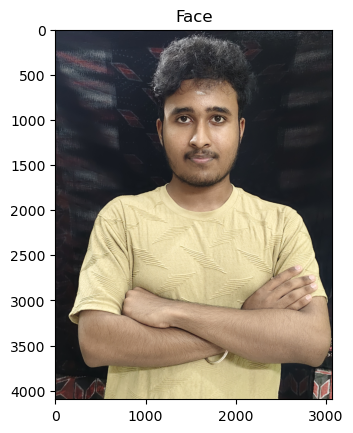

Face Image Dimension = (4096, 3072, 3)


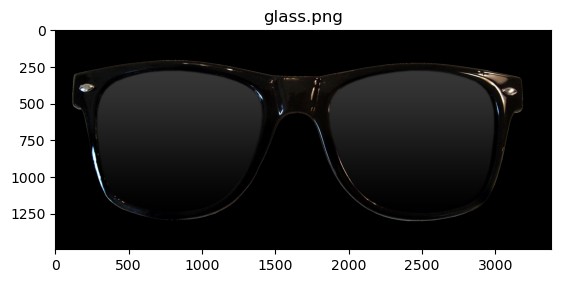

Resized Glass Dimension = (350, 850, 3)


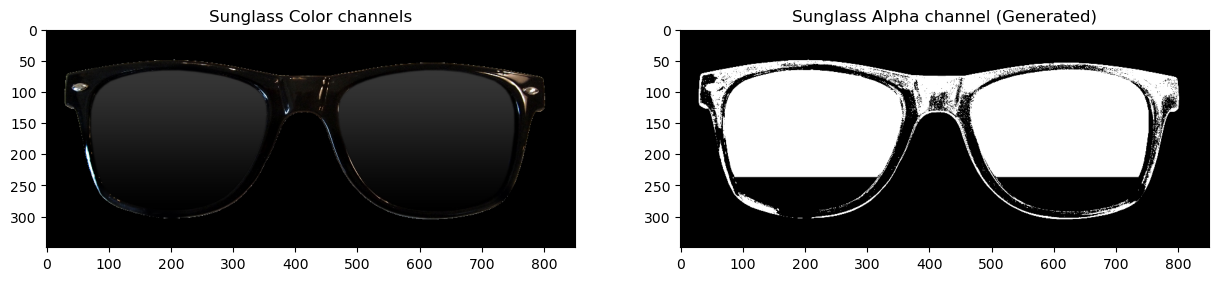

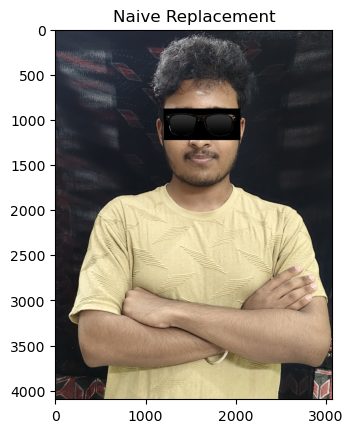

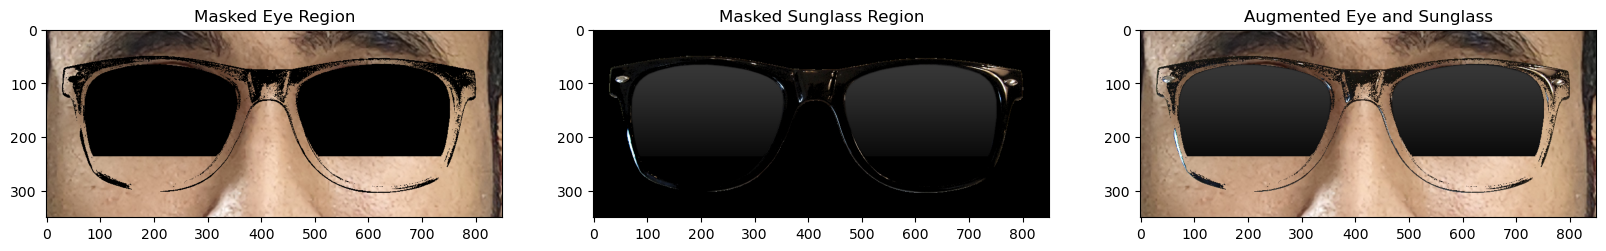

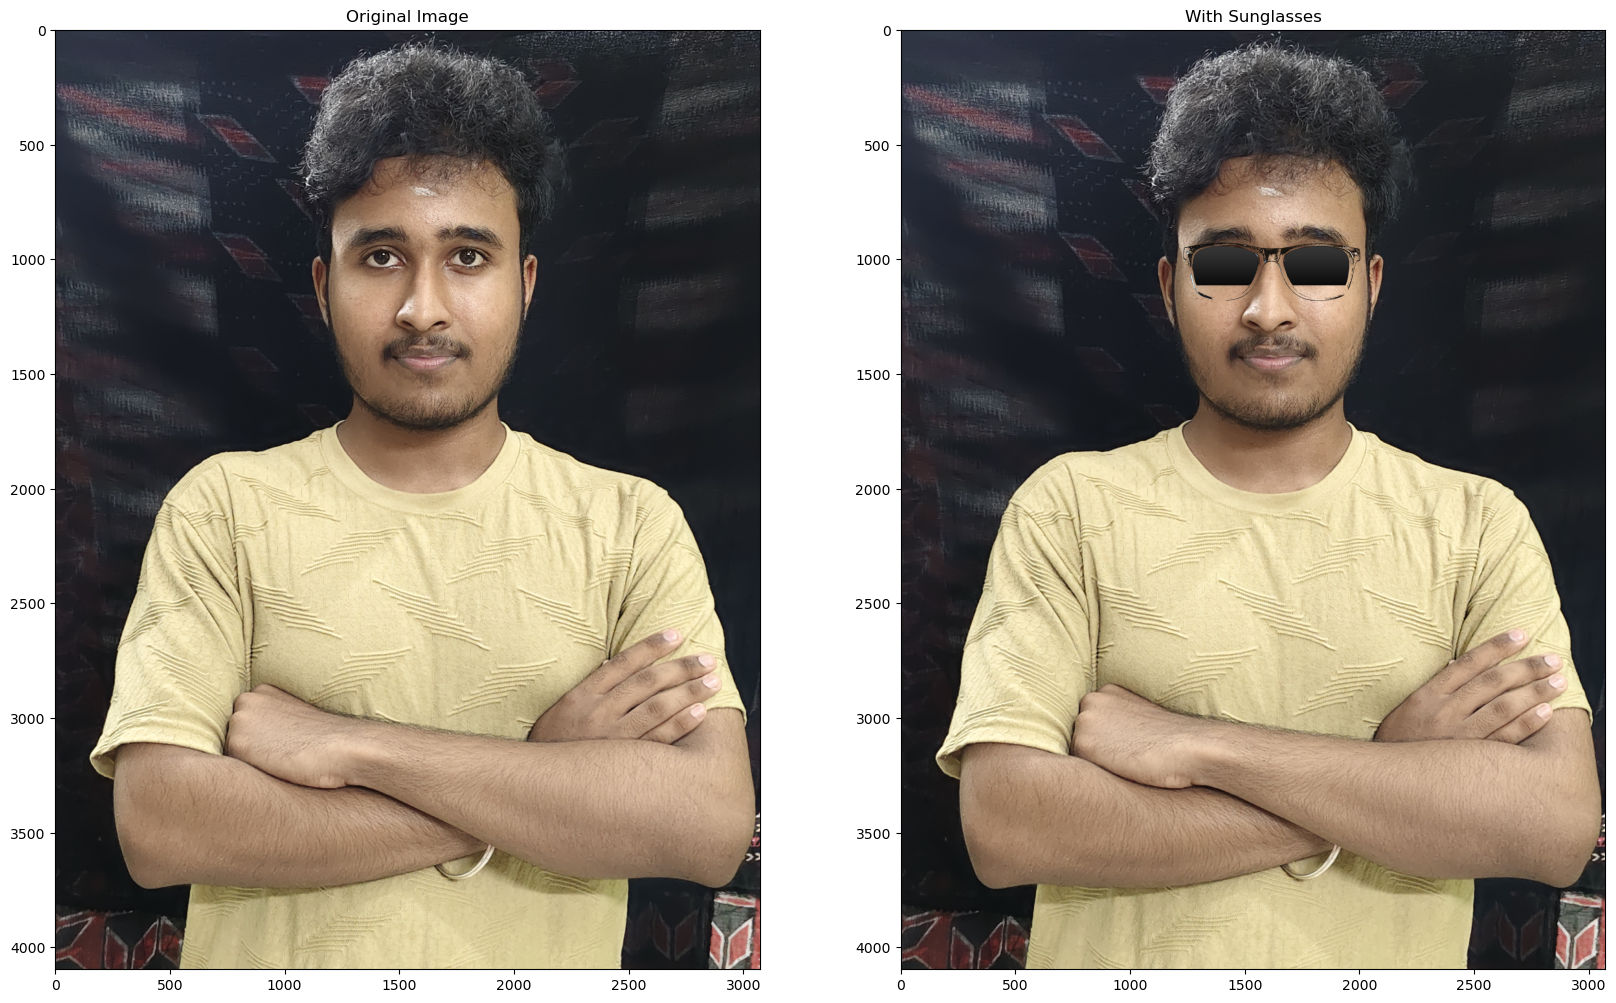

In [8]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the Face Image
faceImage = cv2.imread('25008695.jpg')
plt.imshow(faceImage[:,:,::-1]); plt.title("Face")
plt.show()

print("Face Image Dimension =", faceImage.shape)

# 2. Load the Sunglass image (JPEG with black background)
glass_img = cv2.imread('glass.png')
plt.imshow(glass_img[:,:,::-1]); plt.title("glass.png")
plt.show()

# Create a mask from the black background since it's a JPEG without an alpha channel
glass_gray = cv2.cvtColor(glass_img, cv2.COLOR_BGR2GRAY)
_, glassMask1_full = cv2.threshold(glass_gray, 10, 255, cv2.THRESH_BINARY)

# 3. Define the Region of Interest (ROI) for the boy's eyes
# Tweak these coordinates if the glasses don't align perfectly on your screen
roi_y1, roi_y2 = 880, 1230   # Y-coordinates (Height = 80)
roi_x1, roi_x2 = 1200, 2050   # X-coordinates (Width = 300)

glass_w = roi_x2 - roi_x1
glass_h = roi_y2 - roi_y1

# Resize the sunglasses and the newly created mask to fit over the eye region
glassBGR = cv2.resize(glass_img, (glass_w, glass_h))
glassMask1 = cv2.resize(glassMask1_full, (glass_w, glass_h))
print("Resized Glass Dimension =", glassBGR.shape)

# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121); plt.imshow(glassBGR[:,:,::-1]); plt.title('Sunglass Color channels')
plt.subplot(122); plt.imshow(glassMask1, cmap='gray'); plt.title('Sunglass Alpha channel (Generated)')
plt.show()

# 4. Naive Replacement
faceWithGlassesNaive = faceImage.copy()

# Replace the eye region directly with the sunglass image (will leave a black box around the frames)
faceWithGlassesNaive[roi_y1:roi_y2, roi_x1:roi_x2] = glassBGR

plt.imshow(faceWithGlassesNaive[...,::-1]); plt.title("Naive Replacement")
plt.show()

# 5. Arithmetic Masking for Seamless Blending
# Make the dimensions of the mask same as the input image
glassMask = cv2.merge((glassMask1, glassMask1, glassMask1))

# Make the values [0,1] since we are using arithmetic operations
glassMask = np.uint8(glassMask/255)

# Make a copy of original for arithmetic blending
faceWithGlassesArithmetic = faceImage.copy()

# Get the eye region from the face image
eyeROI = faceWithGlassesArithmetic[roi_y1:roi_y2, roi_x1:roi_x2]

# Use the mask to create the masked eye region (black out the area where glasses will go)
maskedEye = cv2.multiply(eyeROI, (1 - glassMask))

# Use the mask to create the masked sunglass region (black out the background of the glasses)
maskedGlass = cv2.multiply(glassBGR, glassMask)

# Combine the Sunglass in the Eye Region to get the augmented image
eyeRoiFinal = cv2.add(maskedEye, maskedGlass)

# Display the intermediate results
plt.figure(figsize=[20,20])
plt.subplot(131); plt.imshow(maskedEye[...,::-1]); plt.title("Masked Eye Region")
plt.subplot(132); plt.imshow(maskedGlass[...,::-1]); plt.title("Masked Sunglass Region")
plt.subplot(133); plt.imshow(eyeRoiFinal[...,::-1]); plt.title("Augmented Eye and Sunglass")
plt.show()

# Replace the eye ROI with the output from the previous section
faceWithGlassesArithmetic[roi_y1:roi_y2, roi_x1:roi_x2] = eyeRoiFinal

# Display the final result
plt.figure(figsize=[20,20])
plt.subplot(121); plt.imshow(faceImage[:,:,::-1]); plt.title("Original Image")
plt.subplot(122); plt.imshow(faceWithGlassesArithmetic[:,:,::-1]); plt.title("With Sunglasses")
plt.show()
